In [3]:
from aux import *
import matplotlib.pyplot as plt

df = pd.read_pickle("data_family.pkl")
exog = df['exog'].copy().ffill()
sales_by_family = df['sales_by_family']
familias = pd.read_csv("familias.csv")
data_by_family = {
    fam: format_as_year_month(sales_by_family[sales_by_family['family'] == fam].copy())
    for fam in sales_by_family['family'].unique()
}
for fam in data_by_family:
    data_by_family[fam], _ = limpiar_outliers_x_agrupacion(data_by_family[fam], 'family', 'sale_amount_MM')
name = '0312'
target_col = 'sale_amount_MM'
ignore_col = [] 
negatives_reg_col = []
feat = feature_selection(data_by_family[name], exog, max_lag=4, min_lag=-3,
                         target_col=target_col, ignore_col=ignore_col,
                         negatives_reg_col=negatives_reg_col)
feat = feat[feat['correlación'] > 0.4].reset_index(drop=True)
feat = clean_focus_correlation(feat, group='variable', focus='correlación')
feat = feat.sort_values(by='correlación', ascending=False).reset_index(drop=True)
selected, resumen = collinearity_analysis(data_by_family[name], exog, feat, target_col)
feat = feat[feat['variable'].isin(selected)]
df_final = construir_dataset_familia(name, data_by_family, exog, feat, target_col)
splits = generar_splits(df_final)

/Users/sebastianulloa/.virtualenvs/py310/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1179: RuntimeWarning: invalid value encountered in divide
  ret = cvf / (np.std(x) * np.std(y))


In [4]:
familias

,Unnamed: 0,hier_family_cd,hier_family_name
0,0,103,FIERRO/HIERRO/ACERO
1,1,105,OBRA GRUESA
2,2,209,HERRAMIENTAS Y MAQUINARIAS
3,3,415,ILUMINACION Y VENTILADORES
4,4,418,MENAJE
5,5,419,DECORACION
6,6,427,ORGANIZACION
7,7,522,AIRE LIBRE
8,8,104,TABIQUERIA/TECHUMBRE/AISLACION
9,9,206,PLOMERIA / GASFITERIA


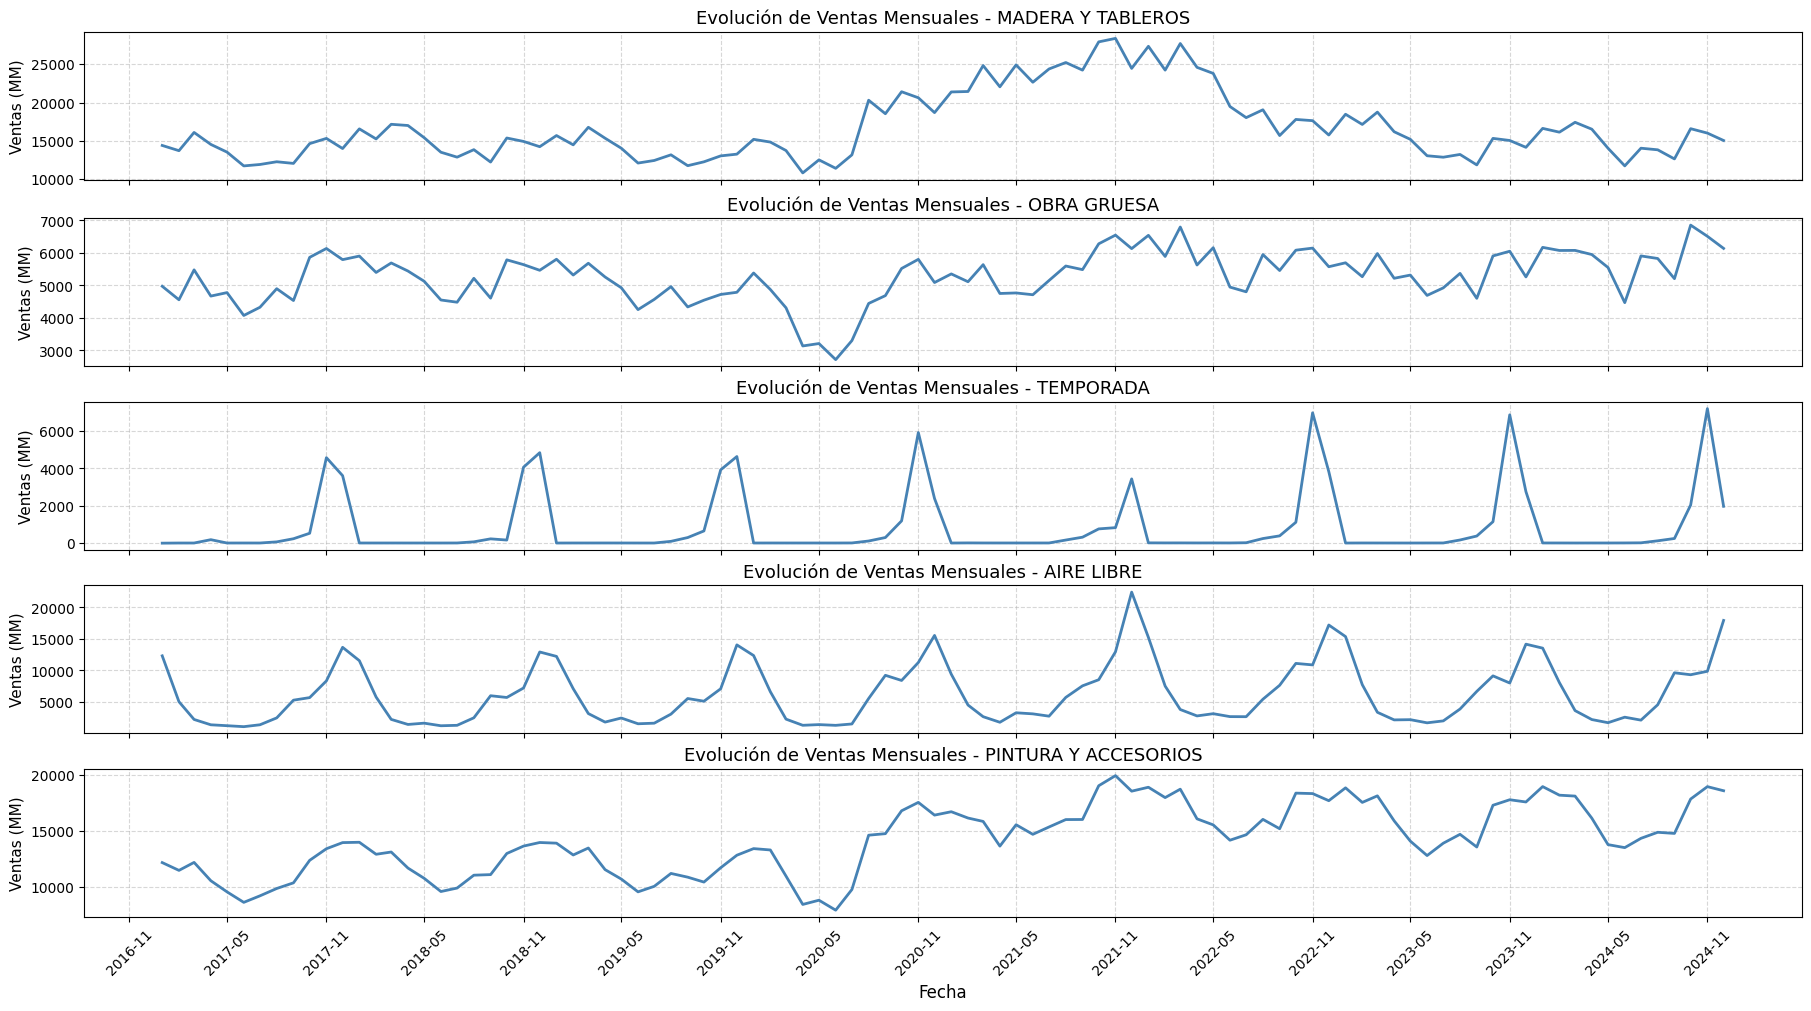

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_family_sales(data_by_family, familias, names, fig_width=18, fig_height=10):
    rows = len(names)
    fig, axes = plt.subplots(rows, 1, figsize=(fig_width, fig_height), sharex=True,
                             constrained_layout=True) 
    if rows == 1:
        axes = [axes]
    for idx, name in enumerate(names):
        serie = data_by_family[name].sale_amount_MM
        x = serie.index
        y = serie.values
        ax = axes[idx]
        ax.plot(x, y, color='steelblue', linewidth=2)
        family_name = familias.loc[familias.hier_family_cd == int(name), 'hier_family_name'].values[0]
        ax.set_title(f"Evolución de Ventas Mensuales - {family_name}", fontsize=13)
        ax.set_ylabel("Ventas (MM)", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        if x.dtype.kind in {'M', 'm'}:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
            ax.tick_params(axis='x', rotation=45)
    axes[-1].set_xlabel("Fecha", fontsize=12)
    plt.show()
names = ['0101', '0105', '0421','0522','0312']  # lista de códigos de familia que quieres graficar
plot_family_sales(data_by_family, familias, names)

In [7]:
%%capture
from optimizers import optimize_hw_cv
from optimizers import optimize_autoarima_cv
from optimizers import optimize_silverkite_cv
from optimizers import optimize_lstm_cv
from optimizers import optimize_gru_cv
from optimizers import optimize_transformer_cv
from optimizers import optimize_elastic_net_cv
from optimizers import optimize_prophet_cv
from optimizers import optimize_mlp_cv
from optimizers import optimize_transformer_cv
from optimizers import optimize_tree_cv
from optimizers import optimize_rf_cv
n_trials=50
best_params_hw, trials_df_hw, model_dict_hw = optimize_hw_cv(df_final, splits, n_trials)
trials_df_hw['model'] = 'holt_winters'
best_params_arima, trials_df_arima, model_dict_arima = optimize_autoarima_cv(df_final, splits, n_trials)
trials_df_arima['model'] = 'auto_arima'
best_params_sk, trials_df_sk, model_dict_sk = optimize_silverkite_cv(df_final, splits, n_trials)
trials_df_sk['model'] = 'silverkite'
best_params_lstm, trials_df_lstm, model_dict_lstm = optimize_lstm_cv(df_final.assign(ds=df_final.index), splits, n_trials)
trials_df_lstm['model'] = 'lstm'
best_params_gru, trials_df_gru, model_dict_gru = optimize_gru_cv(df_final.assign(ds=df_final.index), splits, n_trials)
trials_df_gru['model'] = 'gru'
best_params_trans, trials_df_trans, model_dict_trans = optimize_transformer_cv(df_final.assign(ds=df_final.index), splits, n_trials)
trials_df_trans['model'] = 'transformer'
best_params_enet, trials_df_enet, model_dict_enet = optimize_elastic_net_cv(df_final.assign(ds=df_final.index),splits,n_trials)
trials_df_enet['model'] = 'elastic_net'
best_params_prophet, trials_df_prophet, model_dict_prophet = optimize_prophet_cv(df_final.reset_index(), splits,n_trials)
trials_df_prophet['model'] = 'prophet'
best_params_mlp, trials_df_mlp, model_dict_mlp = optimize_mlp_cv(df_final.assign(ds=df_final.index), splits, n_trials)
trials_df_mlp['model'] = 'MLP'
best_params_transformer, trials_df_transformer, model_dict_transformer = optimize_transformer_cv(df_final.assign(ds=df_final.index), splits, n_trials)
trials_df_transformer['model'] = 'Transformer'
best_params_tree, trials_df_tree, model_dict_tree = optimize_tree_cv(df_final.assign(ds=df_final.index), splits, n_trials)
trials_df_tree['model'] = 'DecisionTree'
best_params_rf, trials_df_rf, model_dict_rf = optimize_rf_cv(df_final.assign(ds=df_final.index), splits, n_trials)
trials_df_rf['model'] = 'RandomForest'

In [8]:
import pandas as pd
import pickle
results = {}
results['trials'] = pd.concat([
    trials_df_hw.assign(model='HW'),
    trials_df_arima.assign(model='SARIMAX'),
    trials_df_sk.assign(model='Silverkite'),
    trials_df_prophet.assign(model='Prophet'),
    trials_df_mlp.assign(model='MLP'),
    trials_df_gru.assign(model='GRU'),
    trials_df_lstm.assign(model='LSTM'),
    trials_df_enet.assign(model='ElasticNet'),
    trials_df_transformer.assign(model='Transformer'),
    trials_df_tree.assign(model='RegresionTree'),
    trials_df_rf.assign(model='RandomForest'),
], ignore_index=True)

results['features']=feat
with open('results'+name+'.pkl', 'wb') as file:
    pickle.dump(results, file)